#### Find E and store it in dataset


In [46]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog
import seaborn as sns

In [47]:
# Ask the user to select a folder containing the data files
root = tk.Tk()
root.withdraw()  # hide the main tkinter window
folder_path = filedialog.askdirectory(title="Please select the folder containing the data files: ")

In [54]:

# Find list of relative paths to .txt files in all the folders and subfolders of the selected folder
txt_files = []
for root_dir, dirs, files in os.walk(folder_path):
    for file in files:
        if file.endswith(".txt"):
            txt_files.append(os.path.relpath(os.path.join(root_dir, file), folder_path))


#remove those in Calib folder and those ending with position.txt
txt_files = [f for f in txt_files if "Calib" not in f and not f.endswith("position.txt")]

print("List of filtered .txt files:")
for f in txt_files:
    print(f)
print("\n")

# create a df to store the results
results_df = pd.DataFrame(columns=["Name", "Folder", "Header line", "X", "Y", "Count", "E[eff] (kPa)", "E[v=0.50] (kPa)"])


# read text file tracking line until you find "Time (s)" then memorize that line and call it header_line
for l in range(len(txt_files)):
    path = os.path.join(folder_path, txt_files[l])
    results_df.loc[l, "Folder"] = os.path.dirname(txt_files[l])
    # Name is until "S-" in the filename
    results_df.loc[l, "Name"] = os.path.basename(txt_files[l]).split("S-")[0]
    with open(path, 'r', encoding='latin-1', errors='replace') as f:
        for i, line in enumerate(f):
            if "Time (s)" in line:
                results_df.loc[l, "Header line"] = i
                break
            if "E[eff]" in line:
                results_df.loc[l, "E[eff] (kPa)"] = (float(line.strip().split('\t')[-1]))/1e3
            if "E[v=0.50]" in line:
                results_df.loc[l, "E[v=0.50] (kPa)"] = (float(line.strip().split('\t')[-1]))/1e3
            if i == 2:
                parts = line.strip().split('\t')
                for idx, part in enumerate(parts[:-1]):
                    if part == "X (#)":
                        results_df.loc[l, "X"] = float(parts[idx + 1])
                    elif part == "Y (#)":
                        results_df.loc[l, "Y"] = float(parts[idx + 1])


# Add an index count per folder
results_df["Count"] = results_df.groupby("Folder").cumcount() + 1
display(results_df)

List of filtered .txt files:
01\Indentations\01 Indentation_001.txt
01\Indentations\01 Indentation_002.txt
01\Indentations\01 Indentation_003.txt
01\Indentations\01 Indentation_004.txt
01\Indentations\01 Indentation_005.txt
01\Indentations\01 Indentation_006.txt
01\Indentations\01 Indentation_007.txt
01\Indentations\01 Indentation_008.txt
01\Indentations\01 Indentation_010.txt
02\Indentations\02 Indentation_001.txt
02\Indentations\02 Indentation_002.txt
02\Indentations\02 Indentation_003.txt
02\Indentations\02 Indentation_004.txt
02\Indentations\02 Indentation_005.txt
02\Indentations\02 Indentation_006.txt
02\Indentations\02 Indentation_007.txt
02\Indentations\02 Indentation_008.txt
02\Indentations\02 Indentation_009.txt
02\Indentations\02 Indentation_010.txt
02\Indentations\02 Indentation_011.txt
02\Indentations\02 Indentation_012.txt
02\Indentations\02 Indentation_013.txt
02\Indentations\02 Indentation_014.txt
02\Indentations\02 Indentation_015.txt
02\Indentations\02 Indentation_016.

,Name,Folder,Header line,X,Y,Count,E[eff] (kPa),E[v=0.50] (kPa)
0,01 Indentation_001.txt,01\Indentations,34,1.0,1.0,1,NaN,NaN
1,01 Indentation_002.txt,01\Indentations,34,1.0,1.0,2,37.314011,27.985508
2,01 Indentation_003.txt,01\Indentations,34,1.0,1.0,3,37.181954,27.886465
3,01 Indentation_004.txt,01\Indentations,34,1.0,1.0,4,38.442891,28.832168
4,01 Indentation_005.txt,01\Indentations,34,1.0,1.0,5,4607213.376255,3455410.032191
...,...,...,...,...,...,...,...,...
120,23 Indentation_005.txt,23\Indentations,34,1.0,1.0,5,13.717616,10.288212
121,23 Indentation_006.txt,23\Indentations,34,1.0,1.0,6,13.660282,10.245212
122,24 Indentation_001.txt,24\Indentations,34,1.0,1.0,1,17.602903,13.202177
123,24 Indentation_002.txt,24\Indentations,34,1.0,1.0,2,18.379786,13.784839


In [55]:
# Remove outliers where E value is more than 1 GPa (1e6 kPa)
results_df = results_df[(results_df["E[eff] (kPa)"] < 1e6) & (results_df["E[v=0.50] (kPa)"] < 1e6)]

# Remove Nan values
results_df = results_df.dropna(subset=["E[eff] (kPa)", "E[v=0.50] (kPa)"])

# Save the results to a CSV file
results_df.to_csv(os.path.join(folder_path, "results.csv"), index=False)

display(results_df)

,Name,Folder,Header line,X,Y,Count,E[eff] (kPa),E[v=0.50] (kPa)
1,01 Indentation_002.txt,01\Indentations,34,1.0,1.0,2,37.314011,27.985508
2,01 Indentation_003.txt,01\Indentations,34,1.0,1.0,3,37.181954,27.886465
3,01 Indentation_004.txt,01\Indentations,34,1.0,1.0,4,38.442891,28.832168
8,01 Indentation_010.txt,01\Indentations,34,1.0,1.0,9,38.319888,28.739916
16,02 Indentation_008.txt,02\Indentations,34,1.0,1.0,8,35.173016,26.379762
...,...,...,...,...,...,...,...,...
120,23 Indentation_005.txt,23\Indentations,34,1.0,1.0,5,13.717616,10.288212
121,23 Indentation_006.txt,23\Indentations,34,1.0,1.0,6,13.660282,10.245212
122,24 Indentation_001.txt,24\Indentations,34,1.0,1.0,1,17.602903,13.202177
123,24 Indentation_002.txt,24\Indentations,34,1.0,1.0,2,18.379786,13.784839


In [56]:
# Aggregate the results by folder and calculate the mean and standard deviation for E[eff] and E[v=0.50]
aggregated_df = results_df.groupby("Folder").agg({"E[eff] (kPa)": ["mean", "std"], "E[v=0.50] (kPa)": ["mean", "std"]})

display(aggregated_df)


E[eff] (kPa)           E[v=0.50] (kPa)          
                        mean       std            mean       std
Folder                                                          
01\Indentations    37.814686  0.658507       28.361014  0.493881
02\Indentations    38.347769  4.563723       28.760826  3.422792
03\Indentations    18.141609  0.170667       13.606206  0.128000
04\Indentations    21.067078  0.833132       15.800308  0.624848
05\Indentations    12.094301  0.223513        9.070725  0.167635
06\Indentations     6.626073  0.180766        4.969555  0.135575
07\Indentations     2.721724  0.351794        2.041293  0.263845
08\Indentations     6.451312  0.292372        4.838484  0.219279
09\Indentations    13.667464  0.821765       10.250598  0.616324
10\Indentations    15.277621  0.463549       11.458216  0.347661
11\Indentations    19.441501  0.576588       14.581126  0.432441
12\Indentations    24.067526  0.621253       18.050645  0.465940
13\Indentations    22.492536  1.351134       16.869402  1.013350
14\Indentations    16.679766  0.306841       12.509824  0.230131
15\Indentations    13.216134  0.095092        9.912101  0.071319
16\Indentations     9.505841  0.037762        7.129381  0.028321
17\Indentations     6.521379  0.092624        4.891034  0.069468
18\Indentations     2.955813  0.373735         2.21686  0.280301
19\Indentations     2.921256  0.037176        2.190941  0.027882
20\Indentations     4.930356  0.034420        3.697767  0.025815
21\Indentations     8.771585  0.332867        6.578689  0.249650
22\Indentations    11.609701  0.231960        8.707275  0.173970
23\Indentations    13.788213  0.138006        10.34116  0.103504
24\Indentations    17.894763  0.422931       13.421072  0.317198

In [60]:
# Model a 24-well plate with counting system 

M = [[19, 20, 21, 22, 23, 24],
    [18, 17, 16, 15, 14, 13],
    [7, 8, 9, 10, 11, 12],
    [6, 5, 4, 3, 2, 1]]

well_plate_matrix = pd.DataFrame(M, columns=["4%", "5%", "6%", "7%", "8%", "9%"], index=["2", "4", "6", "8"])
display(well_plate_matrix)

# place mean E[eff] into a 4x6 matrix according to M
heat = pd.DataFrame(index=well_plate_matrix.index, columns=well_plate_matrix.columns, dtype=float)
std_matrix = pd.DataFrame(index=well_plate_matrix.index, columns=well_plate_matrix.columns, dtype=float)

# map numeric suffix to folder name
num_series = aggregated_df.index.to_series().str.extract(r'(\d+)')[0].dropna().astype(int)
mapping = dict(zip(num_series.values, num_series.index))

for r in range(len(M)):
    for c in range(len(M[0])):
        n = M[r][c]
        if n in mapping:
            folder = mapping[n]
            heat.iloc[r, c] = aggregated_df.loc[folder, ("E[eff] (kPa)", "mean")]
            # make another matrix with std values
            std_matrix.iloc[r, c] = aggregated_df.loc[folder, ("E[eff] (kPa)", "std")]

display(heat)
display(std_matrix)

,4%,5%,6%,7%,8%,9%
2,19,20,21,22,23,24
4,18,17,16,15,14,13
6,7,8,9,10,11,12
8,6,5,4,3,2,1


,4%,5%,6%,7%,8%,9%
2,2.921256,4.930356,8.771585,11.609701,13.788213,17.894763
4,2.955813,6.521379,9.505841,13.216134,16.679766,22.492536
6,2.721724,6.451312,13.667464,15.277621,19.441501,24.067526
8,6.626073,12.094301,21.067078,18.141609,38.347769,37.814686


,4%,5%,6%,7%,8%,9%
2,0.037176,0.034420,0.332867,0.231960,0.138006,0.422931
4,0.373735,0.092624,0.037762,0.095092,0.306841,1.351134
6,0.351794,0.292372,0.821765,0.463549,0.576588,0.621253
8,0.180766,0.223513,0.833132,0.170667,4.563723,0.658507


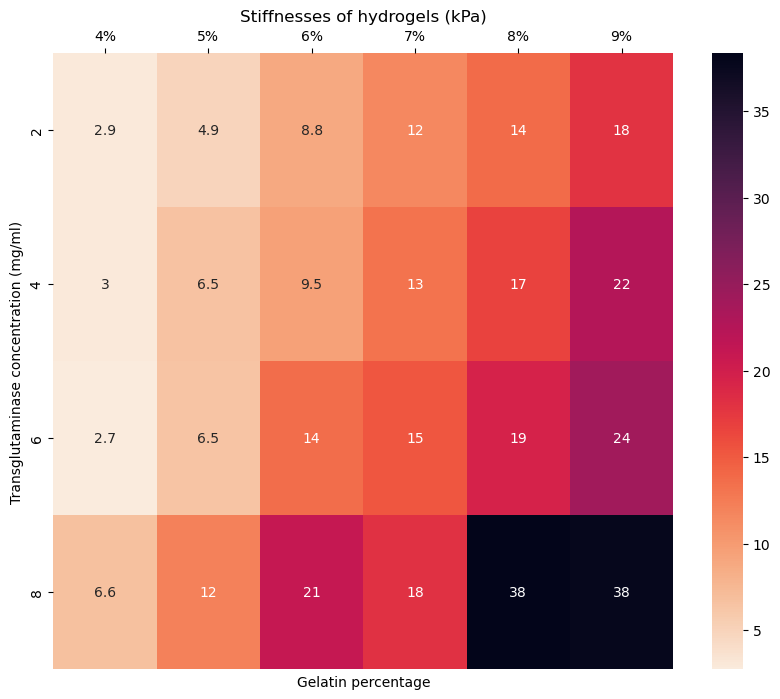

In [61]:
cmap = sns.cm.rocket_r

# add colors representing the values of E[eff] to the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heat, annot=True, cmap=cmap)
plt.xlabel("Gelatin percentage")
plt.ylabel("Transglutaminase concentration (mg/ml)")
plt.gca().xaxis.tick_top()
plt.title("Stiffnesses of hydrogels (kPa)")
plt.show()

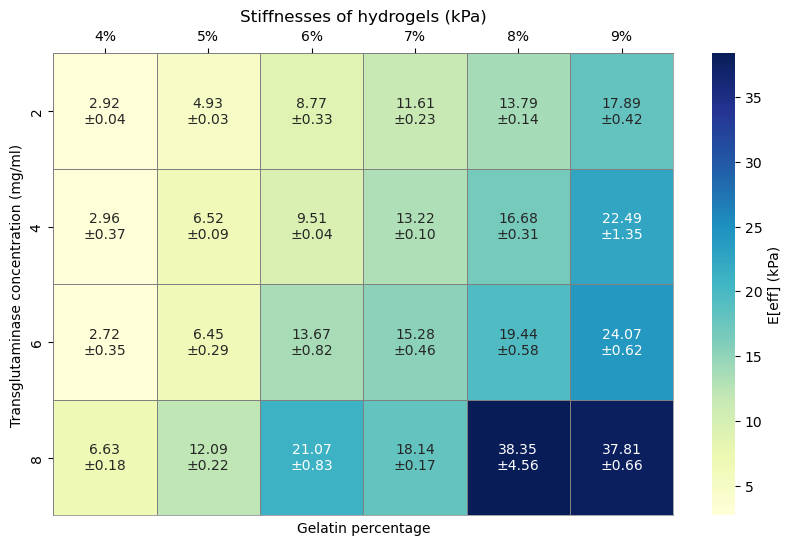

In [62]:

annot = heat.copy().astype(str)
for r in heat.index:
    for c in heat.columns:
        if pd.notna(heat.loc[r, c]):
            mean_val = heat.loc[r, c]
            std_val = std_matrix.loc[r, c]
            if pd.notna(std_val):
                annot.loc[r, c] = f"{mean_val:.2f}\n±{std_val:.2f}"
            else:
                annot.loc[r, c] = f"{mean_val:.2f}"
        else:
            annot.loc[r, c] = ""

plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    heat,
    annot=annot,
    fmt="",
    cmap="YlGnBu",
    cbar_kws={"label": "E[eff] (kPa)"},
    linewidths=0.5,
    linecolor="gray",
)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor("gray")
    spine.set_linewidth(0.5)

plt.xlabel("Gelatin percentage")
plt.ylabel("Transglutaminase concentration (mg/ml)")
plt.gca().xaxis.tick_top()
plt.title("Stiffnesses of hydrogels (kPa)")
plt.show()
